Install the needed libraries

In [1]:
!pip install transformers datasets seqeval accelerate evaluate networkx matplotlib psycopg2-binary sqlalchemy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 53.7 MB/s eta 0:00:0000:0100:01


## **Importing Important Libs**

In [2]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer
)

import networkx as nx
import matplotlib.pyplot as plt


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!ln -s "/content/drive/MyDrive/aviation_data" "/content/aviation_data"


## **Loading the Data**

In [6]:
#df_test = pd.read_csv("data-1770316648579.csv")

#df_test.head()

**Data from Postgres**

In [5]:
df = pd.read_csv("aviation_data/asn_scraped_ds.csv")

df.head(5)

,Unnamed: 0,date,aircraft_type,registration,operator,fatalities,location,category,narrative,sources,aircraft_damage,phase,nature,departure_airport,destination_airport,uid,sanitized_date
0,0,26 May 1948,Lisunov Li-2T,SP-LBC,LOT Polskie Linie Lotnicze,NaN,HRYR,w/o,Written off.,Sources:,"Destroyed, written off",Unknown,Unknown,NaN,NaN,asn_f4840fd1-0139-44a0-85f5-fb6dfd722123,1948-05-26
1,1,18 Feb 2009,Basler BT-67 Turbo 67 (DC-3T),PNC-0211,Servicio Aéreo de Policia,0,HKKI,w/o,The Douglas DC-3C Basler turbo-conversion airc...,Sources:,"Destroyed, written off",Standing,Military,MedellÃ­n-Enrique Olaya Herrera Airport (EOH/S...,QuibdÃ³-El CaraÃ±o Airport (UIB/SKUI),asn_7922f46e-18f0-4671-be5b-d607ef242ed6,2009-02-18
2,2,12 Dec 2008,Let L-410UVP-E,HK-4235,SEARCA-Servicio Aéreo de Capurgana Antes,0,HKNW,sub,The Let 410 suffered a runway excursion on lan...,Sources:,Substantial,Landing,Cargo,MedellÃ­n-Enrique Olaya Herrera Airport (EOH/S...,CapurganÃ¡ Airport (CPB/SKCA),asn_f4692957-9d7b-44d2-9c80-341c2f1f5b11,2008-12-12
3,3,15 Dec 2008,Britten-Norman BN-2A Trislander Mk.III-2,N650LP,Línea Aérea Puertorriqueña - LAP,12,HRYG,mis,The BN-2A Trislander plane operated on a fligh...,Sources:,"Aircraft missing, written off",En route,Passenger - Non-Scheduled/charter/Air Taxi,Santiago de los Caballeros-Cibao International...,Mayaguana Airport (MYG/MYMM),asn_174649d9-17f3-4ad4-8066-11d8202abbf8,2008-12-15
4,4,18 Dec 2008,Beechcraft 200 Super King Air,ZS-NXH,Ferox Investment,0,HUSO,sub,The main gear would not lock in the down posit...,Sources:,"Substantial, repaired",Landing,Executive,Mmabatho Mafikeng International Airport (MBD/F...,Lanseria Airport (HLA/FALA),asn_37991e74-18ac-49f5-b511-07582288d98f,2008-12-18


In [6]:
# Keep only the relevant columns for causal graph pipeline
df = df[['uid', 'narrative', 'phase', 'aircraft_type', 'operator', 'category', 'aircraft_damage']]
df.head()

,uid,narrative,phase,aircraft_type,operator,category,aircraft_damage
0,asn_f4840fd1-0139-44a0-85f5-fb6dfd722123,Written off.,Unknown,Lisunov Li-2T,LOT Polskie Linie Lotnicze,w/o,"Destroyed, written off"
1,asn_7922f46e-18f0-4671-be5b-d607ef242ed6,The Douglas DC-3C Basler turbo-conversion airc...,Standing,Basler BT-67 Turbo 67 (DC-3T),Servicio Aéreo de Policia,w/o,"Destroyed, written off"
2,asn_f4692957-9d7b-44d2-9c80-341c2f1f5b11,The Let 410 suffered a runway excursion on lan...,Landing,Let L-410UVP-E,SEARCA-Servicio Aéreo de Capurgana Antes,sub,Substantial
3,asn_174649d9-17f3-4ad4-8066-11d8202abbf8,The BN-2A Trislander plane operated on a fligh...,En route,Britten-Norman BN-2A Trislander Mk.III-2,Línea Aérea Puertorriqueña - LAP,mis,"Aircraft missing, written off"
4,asn_37991e74-18ac-49f5-b511-07582288d98f,The main gear would not lock in the down posit...,Landing,Beechcraft 200 Super King Air,Ferox Investment,sub,"Substantial, repaired"


In [7]:
# Create the text column
df["text"] = df["narrative"].fillna("") + " " + df["category"].fillna("")

# Keep only the text column, drop missing values, reset index
df_ = df[["text"]].dropna().reset_index(drop=True)

# Select first 2000 rows for training #2000
#df = df_.iloc[:400].reset_index(drop=True)

# Select next 500 rows for testing #100
#test_df = df_.iloc[400:500].reset_index(drop=True)

print("Train size:", len(df))



Train size: 23567


## **NER Labelling Section**

In [8]:
!pip install nltk

In [9]:
# Your specific label mapping
label_to_id = {
    "O": 0,
    "B-ACTOR": 1, "I-ACTOR": 2,
    "B-SYSTEM": 3, "I-SYSTEM": 4,
    "B-PHASE": 5, "I-PHASE": 6,
    "B-TRIGGER": 7, "I-TRIGGER": 8,
    "B-OUTCOME": 9, "I-OUTCOME": 10
}




In [10]:
import json

def load_global_vocab(file_path):
    """Loads the aviation vocabulary from a JSON file."""
    try:
        with open(file_path, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"Error: {file_path} not found. Defaulting to empty vocab.")
        return {"ACTOR": [], "SYSTEM": [], "PHASE": [], "TRIGGER": [], "OUTCOME": []}
    except json.JSONDecodeError:
        print(f"Error: {file_path} contains invalid JSON.")
        return {}

# Replace your hardcoded dictionary with this call
GLOBAL_VOCAB = load_global_vocab("aviation_data/NER_labels_aviation.json")

In [11]:
# Verification (optional)

for category, words in GLOBAL_VOCAB.items():
    print(f"{category}: {len(words)} words loaded.")

ACTOR: 466 words loaded.
SYSTEM: 593 words loaded.
PHASE: 684 words loaded.
TRIGGER: 928 words loaded.
OUTCOME: 804 words loaded.


In [12]:
import nltk
from nltk.tokenize import word_tokenize
# Download the specific resource your error mentioned
nltk.download('punkt_tab')

# Depending on your version/needs, you might also need the basic punkt
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
def rule_based_annotate(row):
    text = str(row['narrative'])
    tokens = word_tokenize(text)
    # Initialize all as 'O'
    ner_tags = [0] * len(tokens)

    # We combine column-specific entities with the global vocab
    
    entities_to_check = {
        "ACTOR": [str(row['operator'])],
        "SYSTEM": [str(row['aircraft_type'])],
        "PHASE": [str(row['phase'])]
    }

    
    for label_type, words in GLOBAL_VOCAB.items():
        entities_to_check.setdefault(label_type, []).extend(words)

    for label_type, search_list in entities_to_check.items():
        #Sort by length descending to match "first officer" before "first"
        sorted_search = sorted([str(s) for s in search_list if len(str(s)) > 2],
                               key=len, reverse=True)

        for entity_str in sorted_search:
            if not entity_str or entity_str.lower() == 'nan':
                continue

            entity_tokens = word_tokenize(entity_str)
            n_entity = len(entity_tokens)

            for i in range(len(tokens) - n_entity + 1):
                
                if ner_tags[i] == 0:
                    if [t.lower() for t in tokens[i:i+n_entity]] == [et.lower() for et in entity_tokens]:
                        ner_tags[i] = label_to_id[f"B-{label_type}"]
                        for j in range(1, n_entity):
                            ner_tags[i + j] = label_to_id[f"I-{label_type}"]

    return tokens, ner_tags



In [ ]:
import pandas as pd
import re
import json

# vocab from the JSON
with open("aviation_data/NER_labels_aviation.json", 'r') as f:
    GLOBAL_VOCAB = json.load(f)



In [ ]:
label_to_id = {
    "O": 0,
    "B-ACTOR": 1, "I-ACTOR": 2,
    "B-SYSTEM": 3, "I-SYSTEM": 4,
    "B-PHASE": 5, "I-PHASE": 6,
    "B-TRIGGER": 7, "I-TRIGGER": 8,
    "B-OUTCOME": 9, "I-OUTCOME": 10
}

#Build optimized lookups
lookup = {}
phrases = []

for category, words in GLOBAL_VOCAB.items():
    for word in words:
        word_lower = word.lower().strip()
        if ' ' in word_lower:
            # re-compile regex and store the category
            phrases.append((re.compile(rf'\b{re.escape(word_lower)}\b'), category))
        else:
            lookup[word_lower] = category

def optimized_annotate(text):
    if not isinstance(text, str) or not text.strip():
        return [], []
    
    
    tokens = text.split() 
    ner_tags = [label_to_id["O"]] * len(tokens)
    
    text_lower = text.lower()
    tokens_lower = [t.lower().strip('.,!?;:()') for t in tokens]

   
    for pattern, category in phrases:
        for match in pattern.finditer(text_lower):
            start_char, end_char = match.span()
            
            #Find which token indices correspond to this character range
            
            start_token_idx = text_lower[:start_char].count(' ')
            num_words_in_match = match.group().count(' ') + 1
            
            for i in range(num_words_in_match):
                idx = start_token_idx + i
                if idx < len(ner_tags):
                    if i == 0:
                        ner_tags[idx] = label_to_id[f"B-{category}"]
                    else:
                        ner_tags[idx] = label_to_id[f"I-{category}"]

    
    for i, t_low in enumerate(tokens_lower):
        if ner_tags[i] == 0 and t_low in lookup:
            category = lookup[t_low]
            ner_tags[i] = label_to_id[f"B-{category}"]
                
    return tokens, ner_tags


text_data = df['narrative'].astype(str).tolist()
results = [optimized_annotate(t) for t in text_data]

df['tokens'] = [r[0] for r in results]
df['ner_tags'] = [r[1] for r in results]

In [16]:
df.tail()

,uid,narrative,phase,aircraft_type,operator,category,aircraft_damage,text,tokens,ner_tags
23562,asn_79dc5654-374f-4047-ba91-f476d0e06445,"The flight was at 13,500 feet overhead the air...",En route,Cessna 208 Caravan I,Skydive Miami,sub,Substantial,"The flight was at 13,500 feet overhead the air...","[The, flight, was, at, 13,500, feet, overhead,...","[0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, ..."
23563,asn_8a2d3092-2f1f-49ce-b30b-4e2f56e67f5b,Ran off the left side of the runway on landing...,Landing,de Havilland Canada DHC-6 Twin Otter 300,Nature Air,min,Minor,Ran off the left side of the runway on landing...,"[Ran, off, the, left, side, of, the, runway, o...","[0, 0, 0, 0, 0, 0, 0, 9, 0, 9, 0, 0, 9, 0, 0, 5]"
23564,asn_b561e50d-3480-4006-a1a6-4cb673ee240e,The Northwestern Air BAe Jetstream 3112 (regis...,Landing,British Aerospace 3112 Jetstream 31,Northwestern Air,sub,"Substantial, written off",The Northwestern Air BAe Jetstream 3112 (regis...,"[The, Northwestern, Air, BAe, Jetstream, 3112,...","[0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 9, 0, 0, 0, ..."
23565,asn_d5b4d8da-ed4e-4877-a51e-e3c76f50bdfd,The Nomad maritime reconnaissance plane took o...,En route,GAF Nomad N.24A,Tentara Nasional Indonesia-AL (Navy),w/o,"Destroyed, written off",The Nomad maritime reconnaissance plane took o...,"[The, Nomad, maritime, reconnaissance, plane, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
23566,asn_4b6e1a4f-0fb1-4164-be7a-34a2fbd50dc4,"Crashed into San Luis hill, some 12 km from Va...",Approach,Yakovlev Yak-42D,Cubana de Aviación,w/o,"Destroyed, written off","Crashed into San Luis hill, some 12 km from Va...","[Crashed, into, San, Luis, hill,, some, 12, km...","[9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


**Create Dataset**

In [17]:
!pip install datasets -qq

In [18]:
from datasets import Dataset, DatasetDict
# Convert to Hugging Face Dataset format
raw_ds = Dataset.from_pandas(df[['uid', 'tokens', 'ner_tags']])

# Split into 80% Train, 10% Validation, 10% Test
train_testvalid = raw_ds.train_test_split(test_size=0.2)
test_valid = train_testvalid['test'].train_test_split(test_size=0.5)

dataset = DatasetDict({
    'train': train_testvalid['train'],
    'validation': test_valid['train'],
    'test': test_valid['test']
})

In [19]:
dataset

DatasetDict({
    train: Dataset({
        features: ['uid', 'tokens', 'ner_tags'],
        num_rows: 18853
    })
    validation: Dataset({
        features: ['uid', 'tokens', 'ner_tags'],
        num_rows: 2357
    })
    test: Dataset({
        features: ['uid', 'tokens', 'ner_tags'],
        num_rows: 2357
    })
})

In [ ]:
#save
import os
drive_path = "/content/drive/MyDrive/aviation_data/aviation_ner_dataset"

#Create the directory if it doesn't exist
os.makedirs(os.path.dirname(drive_path), exist_ok=True)

# Save the DatasetDict directly to Drive
dataset.save_to_disk(drive_path)

Saving the dataset (0/1 shards):   0%|          | 0/18853 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2357 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2357 [00:00<?, ? examples/s]

In [21]:
dataset["train"][12]["tokens"]

['Horizon',
 'Air',
 'Flight',
 '2318,',
 'a',
 'Swearingen',
 'Metro',
 'III',
 'commuter',
 'aircraft,',
 'was',
 'en',
 'route',
 'from',
 'Medford,',
 'Oregon,',
 'to',
 'Portland,',
 'Oregon,',
 'with',
 '13',
 'passengers',
 'and',
 'two',
 'crew',
 'when,',
 'approximately',
 '10',
 'minutes',
 'into',
 'the',
 'flight,',
 'a',
 'male',
 'passenger',
 'approached',
 'the',
 'pilot',
 'and',
 'pressed',
 'a',
 'hard',
 'object,',
 'later',
 'determined',
 'to',
 'be',
 'the',
 'neck',
 'of',
 'a',
 'wine',
 'bottle,',
 'into',
 'his',
 'back.',
 'He',
 'demanded',
 'that',
 'the',
 'aircraft',
 'be',
 'turned',
 'towards',
 'the',
 'south',
 'and',
 'said',
 'that',
 'he',
 'also',
 'had',
 'an',
 'incendiary',
 'device.',
 'The',
 'passenger',
 'had',
 'boarded',
 'the',
 'aircraft',
 'without',
 'a',
 'ticket',
 'and,',
 'without',
 'being',
 'challenged.',
 'He',
 'scaled',
 'a',
 '4-foot',
 'fence',
 'around',
 'the',
 'general',
 'aviation',
 'area',
 'at',
 'the',
 'Medford

## Decoding Labels

In [ ]:
from datasets import Sequence, ClassLabel

label_list = [
            "O",
            "B-ACTOR", "I-ACTOR",
            "B-SYSTEM", "I-SYSTEM",
            "B-PHASE", "I-PHASE",
            "B-TRIGGER", "I-TRIGGER",
            "B-OUTCOME", "I-OUTCOME"
        ]


custom_ner_features = Sequence(
    feature=ClassLabel(
        num_classes=11,
        names=label_list
    )
)
label_names = custom_ner_features.feature.names

In [23]:
words = dataset["train"][12]["tokens"]
labels = dataset["train"][12]["ner_tags"]
line1 = ""
line2 = ""
for word, label in zip(words, labels):
    full_label = label_names[label]
    max_length = max(len(word), len(full_label))
    line1 += word + " " * (max_length - len(word) + 1)
    line2 += full_label + " " * (max_length - len(full_label) + 1)

print(line1)
print(line2)

Horizon Air      Flight    2318, a Swearingen Metro III commuter aircraft, was en       route    from Medford, Oregon, to Portland, Oregon, with 13 passengers and two crew    when, approximately 10 minutes into the flight,   a male passenger approached the pilot     and pressed a hard      object, later determined to be the neck of a wine bottle, into his back. He demanded that the aircraft  be turned towards the south and said that he also had an incendiary device.   The passenger had boarded the aircraft  without a ticket and, without being challenged. He scaled a 4-foot fence around the general aviation area at the Medford Airport and walked the quarter of a mile to the aircraft. He agreed to let the aircraft  land      at the Portland-Hillsborough Airport to refuel and there he demanded water,    four parachutes, and maps of the Phoenix, Arizona, area. During negotiations on the ground, he finally allowed all of the passengers and crew,   except for the pilot,    to deplane; howeve

**Mappings for the Model Config**

In [24]:
# Mappings for the model config
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

**Tokenize and Align Labels**

Because BERT models use WordPiece or Byte-Pair Encoding, a single word like "stabilized" might be split into ["stabil", "##ized"]. We need to ensure the first sub-word keeps the original tag and subsequent sub-words are assigned -100 (so the loss function ignores them).

In [ ]:
def tokenize_and_align_labels(examples, tokenizer):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)  
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                # Special tokens like [CLS] or [SEP]
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                # This is the first sub-token of a word
                label_ids.append(label[word_idx])
            else:
                
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

## **Training Time**

In [29]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
def train_model(model_name, repo_name):
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    tokenized_dataset = dataset.map(
        lambda x: tokenize_and_align_labels(x, tokenizer),
        batched=True
    )

    
    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id
    )

    
    training_args = TrainingArguments(
        output_dir=repo_name,         
        eval_strategy="epoch",    
        eval_steps=50,
        learning_rate=2e-5,
        per_device_train_batch_size=16, 
        num_train_epochs=3,
        weight_decay=0.01,
        save_total_limit=1,
        push_to_hub=True,   
        hub_model_id=repo_name,# Repository name on HF
        report_to="none"                
    )

    data_collator = DataCollatorForTokenClassification(tokenizer)

    #Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        data_collator=data_collator,
        processing_class=tokenizer,
    )

    #Train and Push
    trainer.train()

    
    trainer.push_to_hub(commit_message="End of training")

    return model, tokenizer

In [32]:
bert_model, bert_tokenizer = train_model("bert-base-cased", "theophilusowiti/asn-ner-bert")

mbert_model, mbert_tokenizer = train_model("bert-base-multilingual-cased", "theophilusowiti/asn-ner-mbert")

roberta_model, roberta_tokenizer = train_model("roberta-base", "theophilusowiti/asn-ner-roberta")

aerobert_model, aerobert_tokenizer = train_model("NASA-AIML/MIKA_SafeAeroBERT", "theophilusowiti/asn-ner-aerobert")


Map:   0%|          | 0/18853 [00:00<?, ? examples/s]

Map:   0%|          | 0/2357 [00:00<?, ? examples/s]

Map:   0%|          | 0/2357 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...erobert/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...erobert/model.safetensors:   1%|1         | 5.65MB /  436MB            

## **Inference**

In [ ]:
def extract_entities(text, model, tokenizer):
    device = next(model.parameters()).device
    model.eval() 

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    
    predictions = torch.argmax(outputs.logits, dim=-1)[0].cpu().numpy()

    
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    results = []
    for token, label_id in zip(tokens, predictions):
        
        if token in tokenizer.all_special_tokens:
            continue

        label = model.config.id2label[label_id]

       
        if token.startswith("##"):
            if results:
                results[-1] = (results[-1][0] + token[2:], results[-1][1])
        else:
            results.append((token, label))

    return results

Test the experiment extraction

In [34]:
#sample_text = "The BN-2A Islander CF-ZWF was extensively damaged when it descended into trees shortly after takeoff from Fort Simpson Airport, NT (YFS). Apparently both engines failed due to fuel exhaustion.The aircraft was being flown to refuel."
#sample_text = "The Boeing 737-800 encountered turbulence while descending for arrival. The pilot flying (captain) stated that 26 minutes before the scheduled landing he asked the flight attendants to prepare the cabin earlier than normal due to convective weather along the route of flight. Ten minutes after the announcement the airplane encountered turbulence. The pilot reported that both of the airplane's weather radar systems were turned on, and were scanning at 40 and 80 miles range respectively. He reported that the returns showed no convective activity in the immediate area. Two flight attendants were in the aft galley area, after having secured the main cabin for landing, when the turbulence was encountered. During the encounter the attendants were thrown to the ceiling and one sustained a fractured ankle.Probable Cause: An unexpected encounter with turbulence, during the initial descent for landing"
sample_text = "A USAF C-130 transport plane sustained substantial damage in an emergency landing in a barren field shortly after takeoff from Baghdad. The 38 occupants suffered minor injuries,Sixty seconds after the aircraft began its takeoff roll from Baghdad International Airport, Iraq, at approximately 313 feet above the ground and 163 knots indicated airspeed, the airplane's defensive system activated. The pilot reacted in accordance with applicable directives. After reacting to the defensive alert the crew realized that RPM on engine numbers 1, 3, and 4 had decayed to 60% where it remained for the rest of the flight.After initial analysis. the crew initiated the multiple engine power loss/RPM rollback checklist to regain power on the stalled engines. Due to the low altitude and airspeed at the time of the defensive alert/reaction and the unexpected three engine power loss the crew was unable to complete the checklist and recover the malfunctioning engines. The crew initiated landing gear and flap extension but landed, partially gear down, in a barren field. Part of the main landing gear legs were forced into the fuselage, splitting part of the floor.U.S. Air Force Maintenance and Explosive Ordinance Disposal personnel from the 447th Air Expeditionary Group were called in. They placed explosive charges on the plane and blew up the Hercules on July 7.The Board President could not find clear and convincing evidence to determine the exact cause of the engine power loss. He did find evidence to conclude that several factors combined to significantly contribute to the Mishap Airplane (MA) landing partially gear down. Specifically, a defensive system alert, the aircraft's low altitude and airspeed at the time of the malfunction, and the decision to respond to the alert at low altitude and airspeed combined to result in the MA landing partially gear down.All MA systems and performance were normal prior to the defensive system alert. An undetermined malfunction occurred during the defensive reaction that caused three of the MA's four engines to stabilize at an RPM (60%) which was not sufficient to maintain flight and the low altitude and airspeed at the time of the malfunction limited the time available for situation analysis and recovery.The Mishap Crew (MC) had never been exposed to a loss of three or four engines on takeoff in the C-130H2 simulator which resulted in an emergency situation the MC had not seen before at a low altitude and airspeed. Checklist actions taken by the MC did not recover the engines and the Mishap Pilot (MP) appropriately performed a limited power, controlled descent, and forced landing resulting in only minor injuries."
print("BERT:", extract_entities(sample_text, bert_model, bert_tokenizer))
print("mBERT:", extract_entities(sample_text, mbert_model, mbert_tokenizer))
print("RoBERTa:", extract_entities(sample_text, roberta_model, roberta_tokenizer))
print("AeroBERT:", extract_entities(sample_text, aerobert_model, aerobert_tokenizer))


BERT: [('A', 'O'), ('USAF', 'O'), ('C', 'O'), ('-', 'O'), ('130', 'O'), ('transport', 'O'), ('plane', 'O'), ('sustained', 'O'), ('substantial', 'B-OUTCOME'), ('damage', 'I-OUTCOME'), ('in', 'O'), ('an', 'O'), ('emergency', 'B-OUTCOME'), ('landing', 'I-OUTCOME'), ('in', 'O'), ('a', 'O'), ('barren', 'O'), ('field', 'B-OUTCOME'), ('shortly', 'O'), ('after', 'O'), ('takeoff', 'B-TRIGGER'), ('from', 'O'), ('Baghdad', 'O'), ('.', 'O'), ('The', 'O'), ('38', 'O'), ('occupants', 'O'), ('suffered', 'O'), ('minor', 'B-OUTCOME'), ('injuries', 'I-OUTCOME'), (',', 'O'), ('Sixty', 'O'), ('seconds', 'O'), ('after', 'O'), ('the', 'O'), ('aircraft', 'B-OUTCOME'), ('began', 'O'), ('its', 'O'), ('takeoff', 'B-SYSTEM'), ('roll', 'I-SYSTEM'), ('from', 'O'), ('Baghdad', 'O'), ('International', 'O'), ('Airport', 'O'), (',', 'O'), ('Iraq', 'O'), (',', 'O'), ('at', 'O'), ('approximately', 'O'), ('313', 'O'), ('feet', 'O'), ('above', 'O'), ('the', 'O'), ('ground', 'B-PHASE'), ('and', 'O'), ('163', 'O'), ('knots'

**Evaluation Function**

In [ ]:
import torch
import pandas as pd
from evaluate import load
from tqdm import tqdm
from transformers import DataCollatorForTokenClassification
from torch.utils.data import DataLoader

def evaluate_models_on_test(model_dict, raw_test_dataset):
    """
    model_dict: { "model_name": (model, tokenizer), ... }
    raw_test_dataset: The un-tokenized dataset (containing 'tokens' and 'ner_tags')
    """
    metric = load("seqeval")
    final_results = {}
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for name, (model, tokenizer) in model_dict.items():
        print(f"\n--- Preparing and Evaluating {name} ---")

        
        tokenized_test = raw_test_dataset.map(
            lambda x: tokenize_and_align_labels(x, tokenizer),
            batched=True,
            remove_columns=raw_test_dataset.column_names
        )

        
        data_collator = DataCollatorForTokenClassification(tokenizer)
        test_loader = DataLoader(
            tokenized_test,
            batch_size=16,
            collate_fn=data_collator
        )

        model.to(device)
        model.eval()

        all_predictions = []
        all_labels = []

        
        for batch in tqdm(test_loader, desc=f"Inference"):
            batch = {k: v.to(device) for k, v in batch.items()}

            with torch.no_grad():
                outputs = model(**batch)

            predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            labels = batch["labels"].cpu().numpy()

            
            for i in range(len(labels)):
                # We KEEP "O" here so lengths match for seqeval
                # Seqeval will handle the "O" exclusion automatically in step 5
                true_predictions = [
                    model.config.id2label[p]
                    for (p, l) in zip(predictions[i], labels[i]) if l != -100
                ]
                true_labels = [
                    model.config.id2label[l]
                    for (p, l) in zip(predictions[i], labels[i]) if l != -100
                ]

                all_predictions.append(true_predictions)
                all_labels.append(true_labels)

      
        results = metric.compute(predictions=all_predictions, references=all_labels)

        final_results[name] = {
            "Precision (Entities Only)": results["overall_precision"],
            "Recall (Entities Only)": results["overall_recall"],
            "F1 (Entities Only)": results["overall_f1"],
            "Accuracy (Global)": results["overall_accuracy"]
        }

    return pd.DataFrame(final_results).T, all_predictions, all_labels, metric

In [36]:
from torch.utils.data import DataLoader

models_to_evaluate = {
    "theophilusowiti/asn-ner-bert": (bert_model, bert_tokenizer),
    "theophilusowiti/asn-ner-mbert": (mbert_model, mbert_tokenizer),
    "theophilusowiti/asn-ner-roberta": (roberta_model, roberta_tokenizer),
    "theophilusowiti/asn-ner-aerobert": (aerobert_model, aerobert_tokenizer)
}

# Run the evaluation using the previously defined function
test_results_df, all_predictions, all_labels, metric = evaluate_models_on_test(models_to_evaluate, dataset["test"])

# Display the final performance table



--- Preparing and Evaluating theophilusowiti/asn-ner-bert ---


Map:   0%|          | 0/2357 [00:00<?, ? examples/s]

Inference: 100%|██████████| 148/148 [00:30<00:00,  4.78it/s]



--- Preparing and Evaluating theophilusowiti/asn-ner-mbert ---


Map:   0%|          | 0/2357 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/2357 [00:00<?, ? examples/s]

Inference: 100%|██████████| 148/148 [00:29<00:00,  5.06it/s]



--- Preparing and Evaluating theophilusowiti/asn-ner-aerobert ---


Map:   0%|          | 0/2357 [00:00<?, ? examples/s]

Inference: 100%|██████████| 148/148 [00:29<00:00,  4.98it/s]


In [37]:
test_results_df

,Precision (Entities Only),Recall (Entities Only),F1 (Entities Only),Accuracy (Global)
theophilusowiti/asn-ner-bert,0.931728,0.945738,0.938681,0.982029
theophilusowiti/asn-ner-mbert,0.949104,0.955420,0.952251,0.985562
theophilusowiti/asn-ner-roberta,0.934164,0.948752,0.941402,0.982037
theophilusowiti/asn-ner-aerobert,0.953187,0.957799,0.955487,0.986443


In [ ]:

results = metric.compute(predictions=all_predictions, references=all_labels)
for key in ['ACTOR', 'SYSTEM', 'PHASE', 'TRIGGER', 'OUTCOME']:
    if key in results:
        print(f"{key} F1: {results[key]['f1']:.4f}")

ACTOR F1: 0.9276
SYSTEM F1: 0.9331
PHASE F1: 0.9434
TRIGGER F1: 0.9520
OUTCOME F1: 0.9689


**Classification to ADREP using Logic Based Classifier based on the NERs**

In [39]:
#AI-Generated ADREP map
ADREP_MAP = {
    # 1. SCF-PP: System/Component Failure (Powerplant)
    "engine fire": "SCF-PP", "engine failure": "SCF-PP", "flameout": "SCF-PP", "oil leak": "SCF-PP",
    
    # 2. SCF-NP: System/Component Failure (Non-Powerplant)
    "gear failure": "SCF-NP", "hydraulic leak": "SCF-NP", "avionics": "SCF-NP", "flap failure": "SCF-NP",
    
    # 3. ENV: Environmental (Weather/Turbulence)
    "turbulence": "ENV", "windshear": "ENV", "icing": "ENV", "lightning": "ENV", "thunderstorm": "ENV",
    
    # 4. WILD: Wildlife (Birds/Animals)
    "bird strike": "WILD", "wildlife": "WILD",
    
    # 5. FIRE: Fire/Smoke (Non-engine related)
    "smoke": "FIRE", "cabin fire": "FIRE", "fumes": "FIRE",
    
    # 6. LOC-I: Loss of Control - Inflight
    "stall": "LOC-I", "upset": "LOC-I", "spin": "LOC-I", "unusual attitude": "LOC-I",
    
    # 7. ARC: Abnormal Runway Contact
    "hard landing": "ARC", "tail strike": "ARC", "nose gear collapse": "ARC",
    
    # 8. RE: Runway Excursion
    "overrun": "RE", "veered off": "RE", "excursion": "RE",
    
    # 9. GCOL: Ground Collision
    "collision": "GCOL", "pushed into": "GCOL", "tug": "GCOL",
    
    # 10. FUEL: Fuel Related
    "exhaustion": "FUEL", "starvation": "FUEL", "low fuel": "FUEL", "contamination": "FUEL",
    
    # 11. OTHR: Other (For things that are specific but don't fit above)
    "medical emergency": "OTHR", "laser": "OTHR", "unruly passenger": "OTHR"
}

In [40]:


def classify_adrep(event):
    # Check triggers first as they are the primary accident drivers
    for trigger, pos in event["TRIGGER"]:
        trigger_lower = trigger.lower()
        if trigger_lower in ADREP_MAP:
            return ADREP_MAP[trigger_lower]
    return "OTHER" # The category you are trying to reduce!

# **Part 2: Casual Graph Lab**

In [41]:
def build_event_dict(entities):

    event = {
        "ACTOR": [],
        "SYSTEM": [],
        "PHASE": [],
        "TRIGGER": [],
        "OUTCOME": []
    }

    for word, label in entities:

        #Skip non-entity tokens
        if label == "O":
            continue

        role = label.split("-")[-1]

        if role in event:
            event[role].append(word)

    return event


In [42]:
#data Implementation
def build_causal_graph(event):
    G = nx.DiGraph()

    for trigger in event["TRIGGER"]:
        for outcome in event["OUTCOME"]:
            G.add_edge(trigger, outcome)

    for system in event["SYSTEM"]:
        for trigger in event["TRIGGER"]:
            G.add_edge(system, trigger)

    for actor in event["ACTOR"]:
        for outcome in event["OUTCOME"]:
            G.add_edge(actor, outcome)

    return G


In [43]:
entities = extract_entities(sample_text, aerobert_model, aerobert_tokenizer)
for token, label in entities[:100]:  # first 20 for brevity
    print(token, label)


a O
usaf O
c O
- O
130 O
transport O
plane O
sustained O
substantial B-OUTCOME
damage I-OUTCOME
in O
an O
emergency B-OUTCOME
landing I-OUTCOME
in O
a O
barren O
field B-OUTCOME
shortly O
after O
takeoff B-TRIGGER
from O
baghdad O
. O
the O
38 O
occupants O
suffered O
minor B-OUTCOME
injuries I-OUTCOME
, O
sixty O
seconds O
after O
the O
aircraft B-OUTCOME
began O
its O
takeoff B-SYSTEM
roll I-SYSTEM
from O
baghdad O
international O
airport O
, O
iraq O
, O
at O
approximately O
313 O
feet O
above O
the O
ground B-PHASE
and O
163 O
knots O
indicated O
airspeed O
, O
the O
airplane O
' O
s O
defensive O
system B-SYSTEM
activated O
. O
the O
pilot B-TRIGGER
reacted O
in O
accordance O
with O
applicable O
directives O
. O
after O
reacting O
to O
the O
defensive O
alert B-OUTCOME
the O
crew B-ACTOR
realized O
that O
rpm O
on O
engine B-OUTCOME
numbers O
1 O
, O
3 O
, O
and O
4 O
had O
decayed O
to O


Visualization of the Graph

In [ ]:
def build_research_causal_graph(event, window_size=10):
    G = nx.DiGraph()
    
    # Flatten and sort by narrative position
    all_ents = []
    for role, items in event.items():
        for word, pos in items:
            all_ents.append({'word': word, 'label': role, 'pos': pos})
    all_ents = sorted(all_ents, key=lambda x: x['pos'])

    # Add nodes with labels
    for ent in all_ents:
        G.add_node(ent['word'], label=ent['label'])

    # Sequential Logic with Windowing
    for i, current in enumerate(all_ents):
        look_ahead = all_ents[i+1 : i+1+window_size]

        # TRIGGER -> OUTCOME (The Incident)
        if current['label'] == "TRIGGER":
            for future in look_ahead:
                if future['label'] == "OUTCOME":
                    G.add_edge(current['word'], future['word'], label="caused", color="red")
                    
                    break 

        if current['label'] == "SYSTEM":
            for future in look_ahead:
                if future['label'] == "TRIGGER":
                    G.add_edge(current['word'], future['word'], label="fault", color="purple")
                    break
                    
        if current['label'] == "SYSTEM":
            for other in all_ents:
                if other['label'] == "PHASE":
                    G.add_edge(current['word'], other['word'], label="in phase", color="gray")
                    break

    return G 

In [ ]:

entities = extract_entities(sample_text, aerobert_model, aerobert_tokenizer)

def build_event_dict(entities):
    event = {
        "ACTOR": [], "SYSTEM": [], "PHASE": [],
        "TRIGGER": [], "OUTCOME": []
    }

    
    for idx, (word, label) in enumerate(entities):
        if label == "O":
            continue

        # Convert 'B-TRIGGER' or 'I-TRIGGER' to just 'TRIGGER'
        role = label.split("-")[-1]

        if role in event:
            
            event[role].append((word, idx))

    return event

#THIS is where event is created
event = build_event_dict(entities)

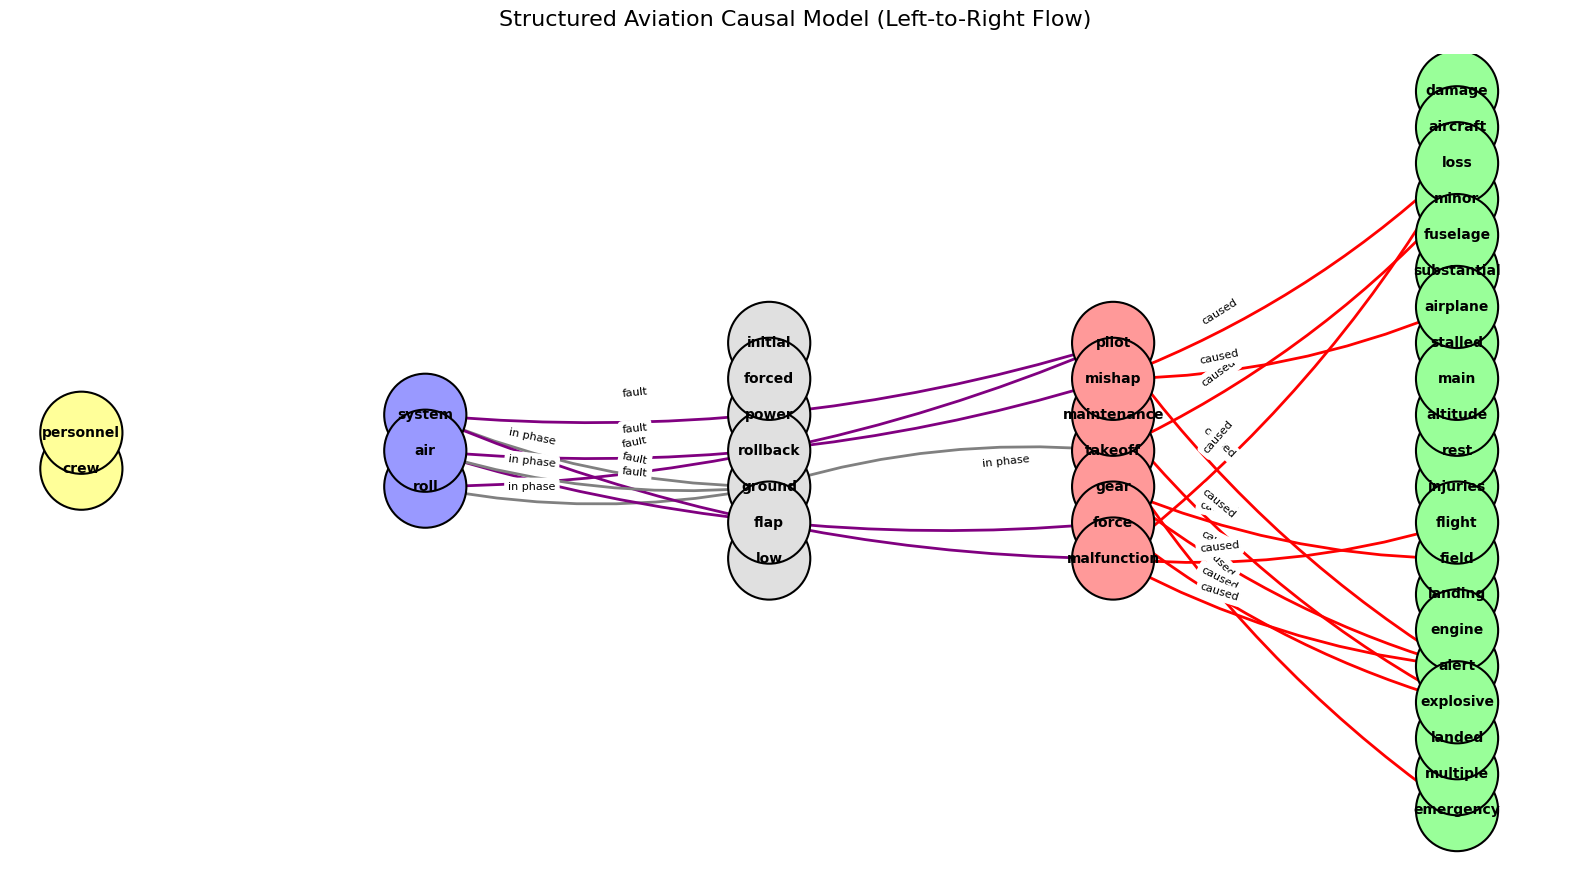

In [ ]:
# Generate the graph using the new constrained logic
G = build_research_causal_graph(event)

# Assign 'layer' attributes for the Multipartite Layout. This forces the graph to flow: Actor -> System -> Phase -> Trigger -> Outcome
layer_map = {"ACTOR": 0, "SYSTEM": 1, "PHASE": 2, "TRIGGER": 3, "OUTCOME": 4}

for node, data in G.nodes(data=True):
    role = data.get('label', "PHASE")
    G.nodes[node]['subset'] = layer_map.get(role, 5)

#Define node colors (Keep your existing color_map)
color_map = {
    "TRIGGER": "#ff9999",   
    "OUTCOME": "#99ff99",   
    "SYSTEM": "#9999ff",    
    "ACTOR": "#ffff99",    
    "PHASE": "#e0e0e0"  
}

#Visualization Setup

plt.figure(figsize=(16, 9))


pos = nx.multipartite_layout(G, subset_key="subset")


node_colors = [color_map.get(G.nodes[node].get('label'), "#lightblue") for node in G.nodes()]


nx.draw_networkx_nodes(G, pos, node_size=3500, node_color=node_colors, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

# Draw Edges (with specific colors from the graph logic)
edges = G.edges(data=True)
if edges:
    edge_colors = [d.get('color', 'gray') for u, v, d in edges]
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2, arrowsize=25, connectionstyle="arc3,rad=0.1")

    # Edge Labels
    edge_labels = nx.get_edge_attributes(G, 'label')
    
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.3)

plt.title("Structured Aviation Causal Model (Left-to-Right Flow)", fontsize=16, pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

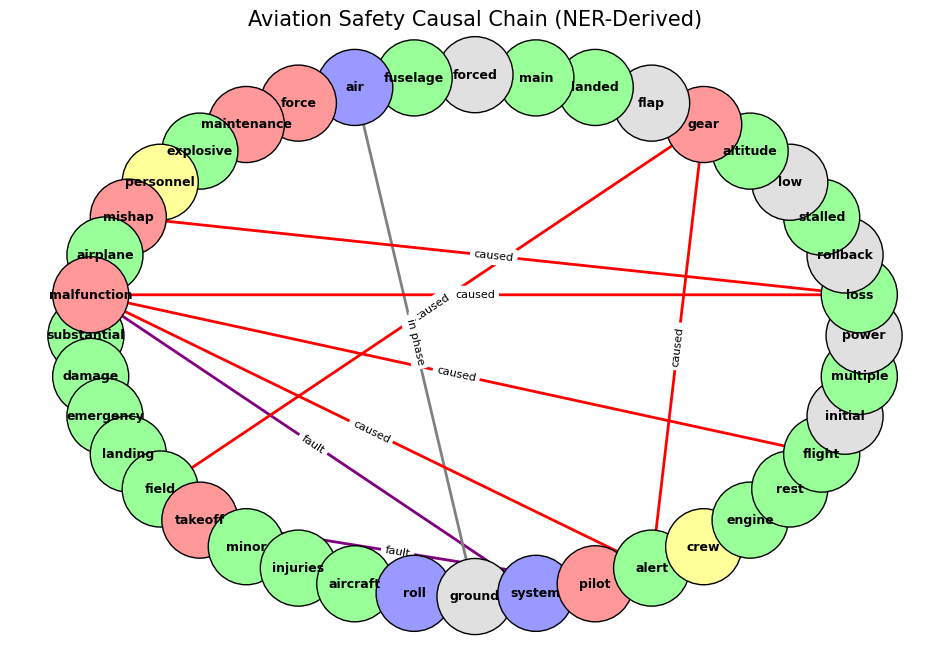

In [ ]:
G = build_research_causal_graph(event)


color_map = {
    "TRIGGER": "#ff9999",   
    "OUTCOME": "#99ff99",  
    "SYSTEM": "#9999ff",    # Blue
    "ACTOR": "#ffff99",     # Yellow
    "PHASE": "#e0e0e0"      # Gray
}

node_colors = [color_map.get(G.nodes[node].get('label', "PHASE"), "#lightblue") for node in G.nodes()]

plt.figure(figsize=(12, 8))
pos = nx.shell_layout(G) 

nx.draw_networkx_nodes(G, pos, node_size=3000, node_color=node_colors, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")


edges = G.edges(data=True)
edge_colors = [d['color'] for u, v, d in edges]
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2, arrowsize=20)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Aviation Safety Causal Chain (NER-Derived)", fontsize=15)
plt.axis("off")
plt.show()

In [49]:
#Re-defined reports using AI
# These are your "new" reports to test the reduction rate
refined_reports = [
    "The approach to landing was normal, but after a firm touchdown, the airplane bounced. The captain initiated a go-around maneuver at low airspeed and high pitch after reverse thrust was selected, contrary to Boeing guidance. The rear fuselage contacted the runway, causing a tailstrike and substantial airframe damage.",
    "A DHC-3 Otter was on takeoff run on Long Lake when a gust lifted the left wing. The right wing contacted the water, and the aircraft overturned. The pilot was uninjured, but the aircraft sustained substantial damage due to wind gusts.",
    "The cargo flight impacted runway barricades during an unauthorized night takeoff on a closed runway. The pilot attempted to maneuver around barricades on a runway listed as out of service in NOTAMs, resulting in a collision with uneven terrain.",
    "During cruise, the aircraft encountered severe turbulence shortly after the seat belt sign was illuminated. A flight attendant was injured during the jolt. FDR data showed vertical acceleration cycles between 1.8 and 0.0 Gs.",
    "During approach to Bodø airport, an asylum seeker attacked the pilots with an axe. Passengers restrained the assailant while the pilots regained control for an emergency landing. Both pilots and a passenger were seriously injured.",
    "During departure from runway 10, the crew heard a loud noise upon releasing brakes. The takeoff was aborted, and the right-hand main gear leg punctured the wing during the turn.",
    "An Antonov en route at FL170 suffered engine problems and diverted to Heglig. The aircraft crashed inverted in a wooded area, resulting in a total loss of life.",
    "The aircraft crashed during operations.", # Minimal report to test 'OTHER' logic
    "During climb at 15,000 feet, the number one engine separated from the pylon due to a turbine disk rim failure. The airplane diverted and landed safely. Investigation revealed improper maintenance of the turbine module.",
    "The aircraft rolled off the runway into a ditch after touchdown because the pilot failed to retard thrust lever 2 to idle. This prevented ground spoilers from deploying and disabled the autobrake system. Number one thrust reverser deployed, but number two remained at partial thrust.",
    "The aircraft landed 40 meters short of runway 16. The nose gear collapsed after striking the raised lip of the runway surface.",
    "A BAe Jetstream 32 crashed during a non-precision instrument approach in IMC. The crew descended below the Minimum Descent Altitude (MDA) without visual cues and struck trees, resulting in a post-crash fire.",
    "The commander aborted takeoff at 165 KIAS (above V1) after hearing a bang and receiving a tower report of smoke. The aircraft overran the runway into sand. The noise was caused by a failed wheel rim on the right body landing gear."
]

In [ ]:
results = []

for text in refined_reports:
    
    entities = extract_entities(text, aerobert_model, aerobert_tokenizer)
    
    
    event = build_event_dict(entities)
    
    
    adrep_class = classify_adrep(event)
    
    results.append({
        "text": text,
        "event_data": event,
        "adrep_label": adrep_class
    })

df_results = pd.DataFrame(results)

In [51]:
df_results

,text,event_data,adrep_label
0,"The approach to landing was normal, but after ...","{'ACTOR': [('captain', 18)], 'SYSTEM': [('guid...",OTHER
1,A DHC-3 Otter was on takeoff run on Long Lake ...,"{'ACTOR': [], 'SYSTEM': [('takeoff', 7), ('run...",OTHER
2,The cargo flight impacted runway barricades du...,"{'ACTOR': [], 'SYSTEM': [], 'PHASE': [], 'TRIG...",OTHER
3,"During cruise, the aircraft encountered severe...","{'ACTOR': [('flight', 18), ('attendant', 19)],...",ENV
4,"During approach to Bodø airport, an asylum see...","{'ACTOR': [('passengers', 16)], 'SYSTEM': [], ...",OTHER
5,"During departure from runway 10, the crew hear...","{'ACTOR': [('crew', 7)], 'SYSTEM': [], 'PHASE'...",OTHER
6,An Antonov en route at FL170 suffered engine p...,"{'ACTOR': [], 'SYSTEM': [('en', 2), ('route', ...",OTHER
7,The aircraft crashed during operations.,"{'ACTOR': [], 'SYSTEM': [], 'PHASE': [], 'TRIG...",OTHER
8,"During climb at 15,000 feet, the number one en...","{'ACTOR': [], 'SYSTEM': [], 'PHASE': [], 'TRIG...",OTHER
9,The aircraft rolled off the runway into a ditc...,"{'ACTOR': [], 'SYSTEM': [('system', 33)], 'PHA...",OTHER


# **Approach 2 (Testing Graph on Knowledge-GRAPH RAG)**

In [ ]:
def get_graph_context(G):
    triples = []
    for u, v, data in G.edges(data=True):
        
        rel = data.get('label', 'is related to')
        triples.append(f"- {u} {rel} {v}")
    
    return "\n".join(triples)


graph_context = get_graph_context(G)

**Bring in LLM Model**

In [ ]:
import json
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Load LLaMA model
#model_name = "meta-llama/Meta-Llama-3-8B-Instruct"  # adjust to your local model
model_name = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
)



config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

**The GraphRAG Inference Loop**

In [ ]:
def predict_adrep_with_llm(report_text, G):
    
    graph_context = get_graph_context(G) 
    
    #Define the ADREP options for the model
    options = "SCF-PP, SCF-NP, ENV, WILD, FIRE, LOC-I, ARC, RE, GCOL, FUEL, OTHR"

    prompt = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an ICAO Aviation Safety Auditor. Your task is to classify the accident report into one of the following ADREP categories:
{options}

GUIDELINES:
- SCF-PP: Powerplant/Engine failures.
- SCF-NP: System failures (Gear, Hydraulics, Avionics).
- ENV: Weather, Turbulence, Icing.
- ARC: Abnormal Runway Contact (Hard landings, Tailstrikes).
- RE: Runway Excursion (Overruns).
- LOC-I: Loss of Control in flight.

CAUSAL GRAPH RELATIONSHIPS:
{graph_context}

REPORT NARRATIVE:
{report_text}
<|eot_id|><|start_header_id|>user<|end_header_id|>
Based on the graph and narrative, what is the single most accurate ADREP category? Respond with only the code.
<|eot_id|><|start_header_id|>assistant<|end_header_id|>"""

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        output = model.generate(
            **inputs, 
            max_new_tokens=10, 
            temperature=0.1, 
            do_sample=False
        )
    
    # Clean the output to get just the code
    prediction = tokenizer.decode(output[0], skip_special_tokens=True).split("assistant")[-1].strip()
    return prediction

In [152]:
all_final_results = []

for text in refined_reports:
    # A. Use your NER model to get entities
    entities = extract_entities(text, aerobert_model, aerobert_tokenizer)
    
    # B. Build the graph object G
    event_dict = build_event_dict(entities)
    G = build_research_causal_graph(event_dict)
    
    # C. Use the LLM to predict the ADREP label using the graph + text
    llm_label = predict_adrep_with_llm(text, G)
    
    all_final_results.append({
        "narrative": text,
        "llm_predicted_adrep": llm_label,
        "causal_nodes": list(G.nodes())
    })

# Convert to DataFrame for your final thesis analysis
df_final = pd.DataFrame(all_final_results)
df_final[['llm_predicted_adrep', 'causal_nodes']]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


,llm_predicted_adrep,causal_nodes
0,SCF-PP,"[approach, landing, touchdown, airplane, capta..."
1,SCF-PP,"[takeoff, run, gust, left, wing, contacted, wa..."
2,SCF-PP,"[cargo, flight, impacted, runway, unauthorized..."
3,SCF-PP,"[cruise, aircraft, severe, turbulence, seat, b..."
4,SCF-PP,"[approach, passengers, emergency, landing, pas..."
5,SCF-PP,"[departure, from, runway, crew, brakes, takeof..."
6,SCF-PP,"[en, route, engine, diverted, aircraft, crashe..."
7,SCF,"[aircraft, crashed]"
8,SCF-PP,"[climb, engine, separated, failure, airplane, ..."
9,SCF-PP,"[aircraft, runway, ditch, touchdown, pilot, th..."
